### Project: Apple Share Price Prediction (Part 2)
Aims: predict the next 10 days (2 weeks) share price based on the last 5 years data

Features used: 
- Open Price
- High Price
- Low Price
- Volume, IXIC (NASDAQ Index)
- GSPC (S&P 500 Index)
- VIX (Volatility Index)
- DX-Y.NYB (US Dollor Index)
- TNX (US Treasury Yield)
- SOX (PHLX Semiconductor Index)

Note: Only using the closed prices for all other index


### Model A1: Feed-Forward Neural Network (MLP) with PyTorch (not in this file)

### Model A2: Feed-Forward Neural Network (MLP) with TensorFlow and Karas (in this file)


In [1]:
import yfinance as yf
apple = yf.Ticker("AAPL")
apple_data = apple.history(period = "5y")
tickers = [ "^IXIC", "^GSPC", "DJI", "^VIX", "DX-Y.NYB", "^TNX", "^SOX"]
others_data = yf.download(tickers, period = "5y")["Close"] # Only using the Close Prices for all indexes


/var/folders/kw/xjs_s57d66dc3cnb0p3gwv180000gn/T/ipykernel_74902/3499833742.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  others_data = yf.download(tickers, period = "5y")["Close"] # Only using the Close Prices for all indexes
[*********************100%***********************]  7 of 7 completed


### Filling the missing value with previous available values

In [2]:
apple_data = apple_data.ffill()

# Checking if there is any missing value in apple_data
apple_data.isna().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [3]:
others_data.ffill()
others_data.isna().sum()

# Note too many missing values in DJI, dropping the DJI column

Ticker
DJI         967
DX-Y.NYB      0
^GSPC         3
^IXIC         3
^SOX          3
^TNX          2
^VIX          3
dtype: int64

In [4]:
others_data.drop(columns = ['DJI'], inplace = True)

In [5]:
others_data.isna().sum()

Ticker
DX-Y.NYB    0
^GSPC       3
^IXIC       3
^SOX        3
^TNX        2
^VIX        3
dtype: int64

In [6]:
others_data.bfill()

Ticker,DX-Y.NYB,^GSPC,^IXIC,^SOX,^TNX,^VIX
Date,,,,,,
2020-12-15,90.470001,3701.169922,12658.190430,2773.419922,0.923,22.889999
2020-12-16,90.449997,3701.169922,12658.190430,2773.419922,0.920,22.500000
2020-12-17,89.820000,3722.479980,12764.750000,2778.139893,0.930,21.930000
2020-12-18,90.019997,3709.409912,12755.639648,2764.739990,0.948,21.570000
2020-12-21,90.040001,3694.919922,12742.519531,2747.290039,0.941,25.160000
...,...,...,...,...,...,...
2025-12-09,99.220001,6840.509766,23576.490234,7372.509766,4.186,16.930000
2025-12-10,98.790001,6886.680176,23654.150391,7467.490234,4.164,15.770000
2025-12-11,98.349998,6901.000000,23593.859375,7411.479980,4.141,14.850000


In [7]:
others_data = others_data.dropna()

In [8]:
others_data.isna().sum()


Ticker
DX-Y.NYB    0
^GSPC       0
^IXIC       0
^SOX        0
^TNX        0
^VIX        0
dtype: int64

In [9]:
print(apple_data.index.tz)  
print(others_data.index.tz)

# Comment: apple_data times are timezone-awared while others_data times are timezone-naive (no timezone)

America/New_York
None


In [10]:
# Convert the times in apple_data to timezone-naive

apple_data.index = apple_data.index.tz_localize(None)

In [11]:
full_df = apple_data.join(others_data, how = "inner")
full_df.drop(columns = ["Dividends", "Stock Splits"], inplace = True)

In [12]:
len(full_df)

1254

In [13]:
full_df.tail(10)

,Open,High,Low,Close,Volume,DX-Y.NYB,^GSPC,^IXIC,^SOX,^TNX,^VIX
Date,,,,,,,,,,,
2025-12-01,278.010010,283.420013,276.140015,283.100006,46587700,99.410004,6812.629883,23275.919922,7020.529785,4.096,17.24
2025-12-02,283.000000,287.399994,282.630005,286.190002,53669500,99.360001,6829.370117,23413.669922,7149.470215,4.086,16.59
2025-12-03,286.200012,288.619995,283.299988,284.149994,43538700,98.849998,6849.720215,23454.089844,7280.509766,4.057,16.08
2025-12-04,284.100006,284.730011,278.589996,280.700012,43989100,98.989998,6857.120117,23505.140625,7215.970215,4.108,15.78
2025-12-05,280.540009,281.140015,278.049988,278.779999,47265800,98.989998,6870.399902,23578.130859,7294.839844,4.139,15.41
2025-12-08,278.130005,279.670013,276.149994,277.890015,38211800,99.089996,6846.509766,23545.900391,7375.220215,4.172,16.66
2025-12-09,278.160004,280.029999,276.920013,277.179993,32193300,99.220001,6840.509766,23576.490234,7372.509766,4.186,16.93
2025-12-10,277.750000,279.750000,276.440002,278.779999,33038300,98.790001,6886.680176,23654.150391,7467.490234,4.164,15.77
2025-12-11,279.100006,279.589996,273.809998,278.029999,33248000,98.349998,6901.000000,23593.859375,7411.479980,4.141,14.85


In [14]:
y = full_df["Close"]
X = full_df.drop(columns = ["Close"])

### Split the data

In [15]:
# Training set = first 70%, validation set = next 15%, test set = next 15%
# Note: 80-10-10 fails when the validation set is too small to be reliable.
n = len(X)
train_end = int(0.7 * n)
validation_end = int(0.85 * n)

X_train = X[:train_end]
X_validation = X[train_end:validation_end]
X_test = X[validation_end:]

y_train = y[:train_end]
y_validation = y[train_end:validation_end]
y_test  = y[validation_end:]

### Scale the data

In [16]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()

# Note: pass the X_train as np.array to prevent the scaler learn the name, if it learn the name and get the df later, it will show a warning (not harmful though)

scaler_X.fit(X_train.values) # fit() learns the statistic from your training data, i.e. means and SDs

scaled_X_train_mlp = scaler_X.transform(X_train.values) # transform() used the learned statistics to apply the scaling

scaled_X_val_mlp = scaler_X.transform(X_validation.values)

scaled_X_test_mlp  = scaler_X.transform(X_test.values) # It uses the learned means and SDs to scale the test data

# Scale y

# Note: Need to reshape y_train, y_validation and y_test as scaler.trainsform() does not accept pandas.Series

y_train = y_train.values.reshape(-1, 1) # In here -1 tell numpy to figure out the number of rows for me, 1 means 1 column

y_validation = y_validation.values.reshape(-1, 1)

y_test = y_test.values.reshape(-1, 1)   # .values converts 1D Series to np.array

scaler_y = StandardScaler()

scaler_y.fit(y_train) 

scaled_y_train_mlp = scaler_y.transform(y_train)

scaled_y_val_mlp = scaler_y.transform(y_validation)

scaled_y_test_mlp = scaler_y.transform(y_test)

### Preprocess the data

Putting 30 days of data into 1 row as X ('Open', 'High', 'Low', 'Volume', 'DX-Y.NYB', '^GSPC', '^IXIC', '^SOX', '^TNX', '^VIX'), the next 10 days data ("Close") as y

In [17]:
import numpy as np

# Need create an overlapping window for X (30 days) to predict y (10 days)
# Reshape the whole dataset such that X = [[day1],[day2],....,[day30]], [day2,....,day31], y = [day31,....,day40], [day32,...,day41]

window_x = 30
window_y = 10

X_train_window = []
X_test_window = []

X_val_window = []
y_val_window = []

y_train_window = []
y_test_window = []

for i in range(window_x, len(scaled_X_train_mlp) - window_y + 1):
    X_train_window.append(scaled_X_train_mlp[i - window_x : i])
    y_train_window.append(scaled_y_train_mlp[i:i + window_y])

for i in range(window_x, len(scaled_X_val_mlp) - window_y + 1):
    X_val_window.append(scaled_X_val_mlp[i - window_x : i])
    y_val_window.append(scaled_y_val_mlp[i:i + window_y])

for i in range(window_x, len(scaled_X_test_mlp) - window_y + 1):
    X_test_window.append(scaled_X_test_mlp[i - window_x : i])
    y_test_window.append(scaled_y_test_mlp[i:i + window_y])




In [18]:
# Convert the all lists from above to np.array

X_train_window = np.array(X_train_window)

y_train_window = np.array(y_train_window)

X_val_window = np.array(X_val_window)

y_val_window = np.array(y_val_window)

X_test_window = np.array(X_test_window)

y_test_window = np.array(y_test_window)

In [19]:
# Flatten X_train_window and X_test_window

X_train_window = X_train_window.reshape(X_train_window.shape[0], X_train_window.shape[1] * X_train_window.shape[2])

X_test_window = X_test_window.reshape(X_test_window.shape[0], X_test_window.shape[1] * X_test_window.shape[2])

# Flatten y_train_window and y_test_window

y_train_window = y_train_window.reshape(y_train_window.shape[0], y_train_window.shape[1])

y_test_window = y_test_window.reshape(y_test_window.shape[0], y_test_window.shape[1])

# Flatten X_val_window and y_val_window

X_val_window = X_val_window.reshape(X_val_window.shape[0], X_val_window.shape[1] * X_val_window.shape[2])

y_val_window = y_val_window.reshape(y_val_window.shape[0], y_val_window.shape[1])

In [20]:
X_train_window.shape

(838, 300)

In [21]:
X_test_window.shape

(150, 300)

In [22]:
X_val_window.shape

(149, 300)

In [23]:
y_train_window.shape

(838, 10)

In [24]:
y_val_window.shape

(149, 10)

In [25]:
y_test_window.shape

(150, 10)

### Scale the data

### MLP: Standard Scaler, inputs centered at around 0 to prevent gradient explodes or vanishes
Gradient vanishing means during backpropagation the gradients become extremely small as they move backward thru the network, resuiting in model learning very slow or not learning at all.

Gradient explosion means that the gradient become extremely large, they model jumps around instead of learning gradually.


### Model A2 - Feed-Forward Neural Network (MLP) with TensorFlow and Karas

### Transfrom the training and testing datasets (both X and y) into tensors (must do before passing them into the model)

In [26]:
import tensorflow as tf
# torch.tensor() is equivalent to tf.convert_to_tensor()
# For NNs, you must convert to float32

X_train_tensor = tf.convert_to_tensor(X_train_window, dtype = tf.float32)

X_validation_tensor = tf.convert_to_tensor(X_val_window, dtype = tf.float32)

X_test_tensor = tf.convert_to_tensor(X_test_window, dtype = tf.float32)

y_train_tensor = tf.convert_to_tensor(y_train_window, dtype = tf.float32)

y_validation_tensor = tf.convert_to_tensor(y_val_window, dtype = tf.float32)

y_test_tensor = tf.convert_to_tensor(y_test_window, dtype = tf.float32)


2025-12-16 10:28:15.486386: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-16 10:28:15.486413: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-16 10:28:15.486417: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-12-16 10:28:15.486435: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-16 10:28:15.486443: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Create Datasets and and load train_dataset and val_dataset (for scalability and performance)

In [27]:
# tf.data.Dataset.from_tensor_slices() takes the full tensors X, and y, splits them into individual samples, creates pairs(X_i, y_i)
# .prefetch(tf.data.AUTOTUNE): GPU does not wait for data, while GPU trains on batch N, CPU prepares batch N + 1


train_dataset = tf.data.Dataset.from_tensor_slices((X_train_tensor, y_train_tensor)).batch(64).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_validation_tensor, y_validation_tensor)).batch(64).prefetch(tf.data.AUTOTUNE)

#### Dynamic MLP class with Keras 
- better than using Sequential() becasue it gives you more control

In [28]:
# import tensorflow as tf

# from tensorflow.keras import layers, models

# input_dim = 300

# model = models.Sequential([
#         layers.Input(shape = (input_dim,)),
#         layers.Dense(128, activation = "gelu"),
#         layers.Dense(128, activation = "gelu"),
#         layers.Dense(10, activation = "linear")
# ])

In [29]:
class FlexibleMLP(tf.keras.Model): # kf.keras.Model is the parent class
    def __init__(self, input_dim, hidden_layers, activations, dropouts, output_dim, **kwargs):
        super().__init__()  # super().__init__() call the constructor(__init__) of the parent class, the FlexibleMLP gets all public methods and behaviours (e.g. self.*)
        
        self.input_dim = input_dim
        self.hidden_layers = hidden_layers
        self.activations = activations
        self.dropouts = dropouts
        self.output_dim = output_dim


        if not (len(hidden_layers) == len(activations) == len(dropouts)):
            raise ValueError("Lengths must match")

        act_map = {
            "relu": tf.keras.layers.ReLU(),
            "gelu": tf.keras.layers.Activation(tf.nn.gelu),
            "tanh": tf.keras.layers.Activation("tanh"),
            "sigmoid": tf.keras.layers.Activation("sigmoid"),
            "elu": tf.keras.layers.ELU(),
        }

        self.layers_list = []

        for h, act, d in zip(hidden_layers, activations, dropouts):
            self.layers_list.append(tf.keras.layers.Dense(h))
            self.layers_list.append(act_map[act]) # Note: activation function is applied after the neuron, which decided whether there will be output passed to the next Dense layer (if not dropout)
            if d > 0:
                self.layers_list.append(tf.keras.layers.Dropout(d))

        self.out = tf.keras.layers.Dense(output_dim)

    def call(self, x, training = False):
        for layer in self.layers_list:
            if isinstance(layer, tf.keras.layers.Dropout):
                x = layer(x, training = training)
            else:
                x = layer(x)
        return self.out(x)

    # get_config(self): to return the configurations of the trained model to Keras, used in model.save("model.keras")
    def get_config(self):
        config = super().get_config() # Get the base Keras configuration for yout model from tf.keras.Model
        config.update({"input_dim": self.input_dim,
                        "hidden_layers": self.hidden_layers,
                        "activations": self.activations,
                        "dropouts": self.dropouts,
                        "output_dim": self.output_dim
                        })

        return config

    # from_config(): returns the configuration of a saved model
    # model = rf.keras.models.load_model("model.keras", custom_objects = {"FlexibleMLP": FlexibleMLP})
    @classmethod
    def from_config(cls, config):
        return cls(**config)    # **config unpacks a dictionary into keyword arguments

            # e.g. 
            # config = {"input_dim": 20,"hidden_layers": [64, 32], "output_dim": 1}

            # FlexibleMLP(**config)

            # FlexibleMLP(input_dim=20,
            #             hidden_layers=[64, 32],
            #             output_dim=1)


### Use Optuna to find the best hyperparameters first

In [30]:
import optuna
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def objective(trial):

    n_layers = trial.suggest_int("n_layers", 1, 4)

    lr = trial.suggest_float("lr", 1e-4, 1e-2, log = True) 

    hidden_layers = []
    activations = []
    dropouts = []
    
    possible_units = [512, 256, 128, 64, 32]

    current_index = 0

    for i in range(n_layers):

        drop_step = trial.suggest_int(f"layer_{i}_drop", 0, 2)

        current_index = min(current_index + drop_step, len(possible_units) - 1)

        units = possible_units[current_index]

        hidden_layers.append(units)

        activations.append(trial.suggest_categorical(f"activation_{i}",["relu", "gelu", "tanh", "sigmoid"]))

        dropouts.append(trial.suggest_float(f"dropout_{i}",0.0, 0.5))


    model = FlexibleMLP(input_dim = X_train_tensor.shape[1],
                        hidden_layers = hidden_layers,
                        activations = activations,
                        dropouts = dropouts,
                        output_dim = 10)

    model.compile(optimizer = tf.keras.optimizers.AdamW(learning_rate = lr, weight_decay= 0.0001), loss = "mse")

    history = model.fit(train_dataset,
                        validation_data = val_dataset,
                        epochs = 50,
                        callbacks=[tf.keras.callbacks.EarlyStopping(patience = 5, restore_best_weights = True)], 
                        # After 5 epoches, if there is no improvement, stop, then the model rolls back to the epoch with min val_loss to find the best params
                        verbose = 0)

    return min(history.history["val_loss"]) # it is the mean loss (total_loss/n_samples in val_dataset)


In [31]:
import optuna

study = optuna.create_study(direction = "minimize")

[I 2025-12-16 10:28:15,578] A new study created in memory with name: no-name-8faa888c-65e8-4ba8-9735-61262178780c


In [32]:
study.optimize(objective, n_trials = 20)

2025-12-16 10:28:15.768732: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
[I 2025-12-16 10:28:16,966] Trial 0 finished with value: 3.5861473083496094 and parameters: {'n_layers': 1, 'lr': 0.0015800827030578433, 'layer_0_drop': 1, 'activation_0': 'sigmoid', 'dropout_0': 0.28367193409142355}. Best is trial 0 with value: 3.5861473083496094.
[I 2025-12-16 10:28:19,061] Trial 1 finished with value: 2.582979917526245 and parameters: {'n_layers': 3, 'lr': 0.0002827148232768072, 'layer_0_drop': 0, 'activation_0': 'gelu', 'dropout_0': 0.2904027471821862, 'layer_1_drop': 1, 'activation_1': 'tanh', 'dropout_1': 0.04115667720420979, 'layer_2_drop': 1, 'activation_2': 'gelu', 'dropout_2': 0.13508621219269606}. Best is trial 1 with value: 2.582979917526245.
[I 2025-12-16 10:28:20,444] Trial 2 finished with value: 3.512035846710205 and parameters: {'n_layers': 1, 'lr': 0.0011713087816144136, 'layer_0_drop': 1, 'activatio

In [33]:
print(f"Best hyperparameters: {study.best_params}")
print(f"Best validation loss: {study.best_value:.4f}")

Best hyperparameters: {'n_layers': 2, 'lr': 0.0005787942258365889, 'layer_0_drop': 2, 'activation_0': 'relu', 'dropout_0': 0.0725100714028103, 'layer_1_drop': 0, 'activation_1': 'gelu', 'dropout_1': 0.17674146263542162}
Best validation loss: 0.6074


### Extract the number of neurons, activation functions, dropout rates 

In [34]:
# Extract the number of neurons for each layer
num_neurons_ls = []
possible_units = [512, 256, 128, 64, 32]
for i in range(study.best_params["n_layers"]):
    num_neurons = study.best_params[f"layer_{i}_drop"]
    num_neurons_ls.append(possible_units[num_neurons])

In [35]:
num_neurons_ls

[128, 512]

In [36]:
# Extract the activation function for each layer
act_fun_ls = []
for i in range(study.best_params["n_layers"]):
    act_fun = study.best_params[f"activation_{i}"]
    act_fun_ls.append(act_fun)

In [37]:
act_fun_ls 

['relu', 'gelu']

In [38]:
# Extract the dropout for each layer
dropout_ls = []
for i in range(study.best_params["n_layers"]):
    dropout = study.best_params[f"dropout_{i}"]
    dropout_ls.append(dropout)


In [39]:
dropout_ls

[0.0725100714028103, 0.17674146263542162]

### Build, complie, and train the Model with the best hyperparameters

In [40]:
model = FlexibleMLP(input_dim = X_train_tensor.shape[1],
                    hidden_layers = num_neurons_ls,
                    activations = act_fun_ls,
                    dropouts = dropout_ls,
                    output_dim = y_train_tensor.shape[1])


In [41]:
model.compile(optimizer = tf.keras.optimizers.AdamW(learning_rate = study.best_params["lr"], weight_decay= 0.0001), loss = "mse")

In [42]:
history = model.fit(train_dataset,
                    validation_data = val_dataset,
                    epochs = 50,
                    callbacks=[tf.keras.callbacks.EarlyStopping(patience = 5, restore_best_weights = True)],
                    verbose = 0)

### Evaluate the model with test dataset

In [43]:
test_loss = model.evaluate(X_test_tensor, y_test_tensor, verbose = 1)
print("Test MSE:", test_loss)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7728 
Test MSE: 0.7728142738342285


### Save the Model

In [44]:
import tensorflow as tf

model.save("mlp_model_tensorflow.keras")

### Retrieve the saved Model

In [45]:
model = tf.keras.models.load_model(
    "mlp_model_tensorflow.keras",
    custom_objects = {"FlexibleMLP": FlexibleMLP})


In [46]:
last_40_days_df = full_df.iloc[-40:]

In [47]:
cols = ['Open', 'High', 'Low', 'Volume', 'DX-Y.NYB', '^GSPC', '^IXIC', '^SOX', '^TNX', '^VIX']
X_30_days = last_40_days_df[cols].iloc[:-10]


In [48]:
X_30_days

,Open,High,Low,Volume,DX-Y.NYB,^GSPC,^IXIC,^SOX,^TNX,^VIX
Date,,,,,,,,,,
2025-10-17,247.779801,253.134610,247.030527,49147000,98.430000,6664.009766,22679.970703,6777.979980,4.007,20.780001
2025-10-20,255.642182,264.123965,255.382439,90483000,98.589996,6735.129883,22990.539062,6885.029785,3.986,18.230000
2025-10-21,261.626381,265.033082,261.576411,46695900,98.930000,6735.350098,22953.669922,6839.270020,3.963,17.870001
2025-10-22,262.395621,262.595440,255.182612,45015300,98.900002,6699.399902,22740.400391,6677.569824,3.953,18.600000
2025-10-23,259.688250,260.367584,257.760126,32754900,98.940002,6738.439941,22941.800781,6847.390137,3.991,17.299999
2025-10-24,260.937064,263.874220,258.929001,38253700,98.949997,6791.689941,23204.869141,6976.939941,3.997,16.370001
2025-10-27,264.623466,268.859349,264.393677,44888200,98.779999,6875.160156,23637.460938,7167.979980,3.997,15.790000
2025-10-28,268.729471,269.628624,267.890289,41534800,98.690002,6890.890137,23827.490234,7194.709961,3.983,16.420000
2025-10-29,269.019206,271.147148,266.851294,51086700,99.220001,6890.589844,23958.470703,7327.930176,4.058,16.920000


### Transform the current 30 days of data

In [49]:
X_30_days_scaled = scaler_X.transform(X_30_days)


/Users/yukpinglee/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [50]:
X_30_days_scaled.shape

(30, 10)

### Flatten the current 30 days of data

In [51]:
num_of_samples = 1
window_x = 30
num_features = X_30_days_scaled.shape[1]
X_30_days_scaled = X_30_days_scaled.reshape(num_of_samples, window_x * num_features)


In [52]:
X_30_days_scaled.shape

(1, 300)

In [53]:
y_true = d=full_df["Close"].iloc[-10:]

In [54]:
y_true

Date
2025-12-01    283.100006
2025-12-02    286.190002
2025-12-03    284.149994
2025-12-04    280.700012
2025-12-05    278.779999
2025-12-08    277.890015
2025-12-09    277.179993
2025-12-10    278.779999
2025-12-11    278.029999
2025-12-15    274.109985
Name: Close, dtype: float64

In [55]:
y_pred_scaled = model.predict(X_30_days_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


In [56]:
y_pred_scaled

array([[4.7924314, 7.243155 , 4.710083 , 6.0445895, 4.645942 , 5.7370186,
        5.550578 , 4.492757 , 5.780098 , 4.9862504]], dtype=float32)

In [57]:
y_pred = scaler_y.inverse_transform(y_pred_scaled)

In [58]:
y_pred

array([[257.95038, 309.82538, 256.2073 , 284.45508, 254.84962, 277.94467,
        273.99823, 251.60712, 278.85654, 262.053  ]], dtype=float32)

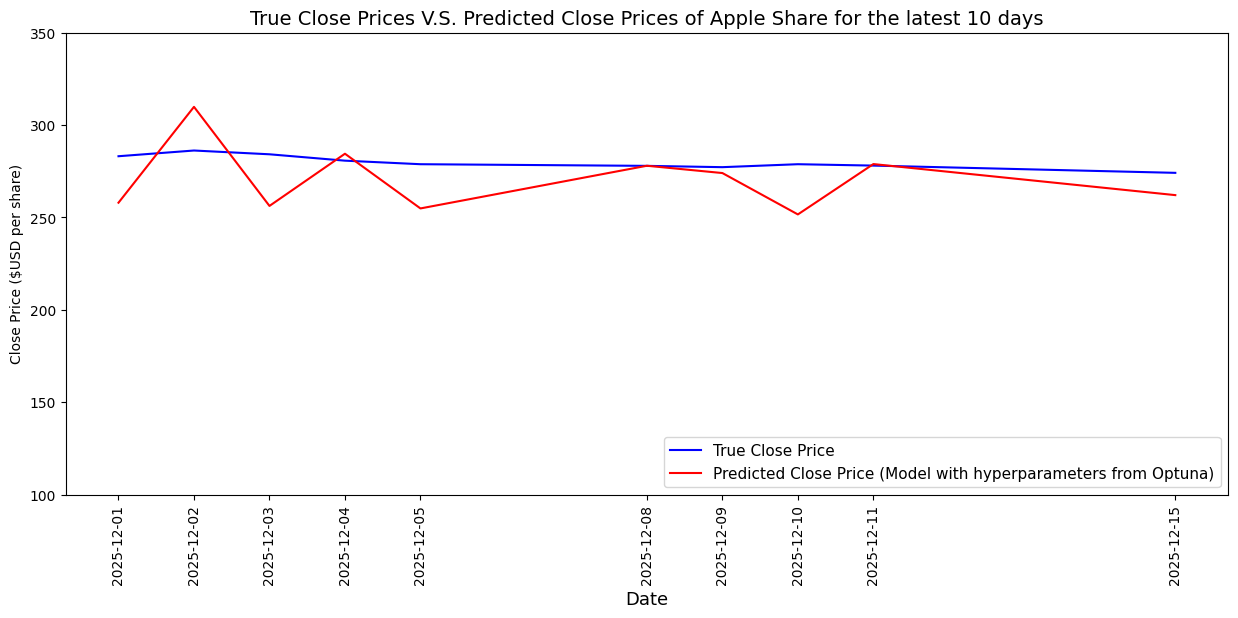

In [59]:
import matplotlib.pyplot as plt
plt.figure(figsize = (15, 6))

plt.plot(y_true.index.ravel(), y_true.values.ravel(), color = "blue", label = "True Close Price")
plt.plot(y_true.index.ravel(), y_pred.ravel(), color = "red", label = "Predicted Close Price (Model with hyperparameters from Optuna)")


# Force ticks to use all index values
plt.gca().set_xticks(y_true.index)
plt.gca().set_xticklabels(y_true.index.strftime("%Y-%m-%d"), rotation = 90)

plt.title("True Close Prices V.S. Predicted Close Prices of Apple Share for the latest 10 days", fontsize = 14)
plt.xlabel("Date", fontsize = 13)
plt.legend(loc = "lower right", fontsize = 11)

plt.ylim(100,350)
plt.ylabel("Close Price ($USD per share)")
plt.show()

In [60]:
# Average daily error
total_errors_best = abs(y_true.values.ravel() - y_pred.ravel())
average_error_best = sum(total_errors_best)/10
print(f"The Average Daily Prediction Error for the latest 10 days is $USD {average_error_best:.2f}.")


The Average Daily Prediction Error for the latest 10 days is $USD 14.77.
